In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('adult_with_headers (1).csv')
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.describe(include = 'object')

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


## Handle Missing Values

In [6]:
for column in df.select_dtypes(include="object").columns: 
    df[column] = df[column].str.strip()

In [7]:
df = df.replace("?", np.nan)
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [8]:
numerical_columns = df.select_dtypes( include=["int64", "float64"] ).columns.tolist() 
categorical_columns = df.select_dtypes( include=["object"] ).columns.tolist()

In [9]:
for column in numerical_columns:
    df[column] = df[column].fillna( df[column].median() )

In [10]:
for column in categorical_columns: 
    df[column] = df[column].fillna( df[column].mode()[0] )

In [11]:
print("\nMissing Values After Handling:") 
print(df.isnull().sum())


Missing Values After Handling:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [12]:
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])

In [13]:
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])

In [14]:
df['native_country'] = df['native_country'].fillna(df['native_country'].mode()[0])

In [15]:
df['workclass'].isnull().sum()
df['occupation'].isnull().sum()
df['native_country'].isnull().sum()

np.int64(0)

### Handling Missing Values

I first checked for missing values in the dataset. The dataset uses " ?" to represent missing values in some categorical columns.

I converted these values to NaN and then filled the missing values in workclass, occupation, and native_country using the mode of each column.

I used the mode because these are categorical variables, and the most frequently occurring category is more appropriate than using a mean or median.

After filling the missing values, I checked the columns again and confirmed that there were no remaining missing values.


### Identify numerical columns

In [16]:
bn=df.select_dtypes(include=['number']).columns
print(bn)

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')


### StandardScaler

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler=StandardScaler()

In [19]:
sc_df = pd.DataFrame(scaler.fit_transform(df[bn]), columns=bn)
sc_df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04,3.256100e+04
mean,-2.662271e-17,-9.732565e-17,1.479525e-16,5.237255e-18,-4.364379e-17,-2.574984e-17
std,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,-1.582206e+00,-1.681631e+00,-3.529656e+00,-1.459205e-01,-2.166595e-01,-3.194030e+00
25%,-7.757679e-01,-6.816910e-01,-4.200596e-01,-1.459205e-01,-2.166595e-01,-3.542945e-02
50%,-1.159546e-01,-1.082193e-01,-3.136003e-02,-1.459205e-01,-2.166595e-01,-3.542945e-02
75%,6.904838e-01,4.478765e-01,7.460392e-01,-1.459205e-01,-2.166595e-01,3.695194e-01
max,3.769612e+00,1.226856e+01,2.300838e+00,1.339458e+01,1.059351e+01,4.742967e+00


### Standard Scaling

I applied StandardScaler to the numerical features. Standardization changes the features so that they have a mean close to 0 and a standard deviation close to 1.

This is useful when numerical variables have very different ranges, especially for machine learning algorithms that are sensitive to feature scale.

The output confirms that the means are approximately 0 and the standard deviations are approximately 1.


### MinMaxScaler

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [21]:
minmax=MinMaxScaler()

In [22]:
mm_df = pd.DataFrame(
    minmax.fit_transform(df[bn]),
    columns=bn
)

In [23]:
mm_df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,0.295639,0.120545,0.605379,0.010777,0.020042,0.402423
std,0.186855,0.071685,0.171515,0.073854,0.092507,0.125994
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.150685,0.071679,0.533333,0.000000,0.000000,0.397959
50%,0.273973,0.112788,0.600000,0.000000,0.000000,0.397959
75%,0.424658,0.152651,0.733333,0.000000,0.000000,0.448980
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Min-Max Scaling

I applied Min-Max Scaling to the numerical features. This transformation converts the values into a common range from 0 to 1.

This can be useful when I want all numerical features to have a similar range without changing their relative distribution.

The output confirms that the minimum value is 0 and the maximum value is 1 for each numerical feature.

In [27]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [28]:
for column in cat_cols:
    print(column, ":", df[column].nunique())

workclass : 8
education : 16
marital_status : 7
occupation : 14
relationship : 6
race : 5
sex : 2
native_country : 41
income : 2


## One-Hot Encoding

In [29]:
from sklearn.preprocessing import OneHotEncoder

In [30]:
encoder=OneHotEncoder(sparse_output=False)

In [31]:
sex_encoded = encoder.fit_transform(df[['sex']])
sex_df = pd.DataFrame(sex_encoded,columns=encoder.get_feature_names_out(['sex']))
sex_df.head()

,sex_Female,sex_Male
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0


In [32]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [33]:
income_encoded = encoder.fit_transform(df[['income']])
income_df=pd.DataFrame(income_encoded,columns=encoder.get_feature_names_out(['income']))
income_df.head()

,income_<=50K,income_>50K
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0


In [34]:
df['race'].unique()

array(['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo',
       'Other'], dtype=object)

### Handling the race column

The race column contains exactly 5 unique categories. Since the assignment specifies rules for fewer than 5 and more than 5 categories, it does not explicitly define the case of exactly 5 categories.So I used One-Hot Encoding for this column because it avoids introducing an artificial numerical order between the categories.

In [35]:
race_encoded=encoder.fit_transform(df[['race']])
race_df=pd.DataFrame(race_encoded,columns=encoder.get_feature_names_out(['race']))
race_df.head()

,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0


### Label Encoding

In [37]:
from sklearn.preprocessing import LabelEncoder

In [38]:
le=LabelEncoder()
df['workclass_encoded']=le.fit_transform(df['workclass'])
df[['workclass','workclass_encoded']].head(10)

,workclass,workclass_encoded
0,State-gov,6
1,Self-emp-not-inc,5
2,Private,3
3,Private,3
4,Private,3
5,Private,3
6,Private,3
7,Self-emp-not-inc,5
8,Private,3
9,Private,3


In [39]:
label_columns=['education','marital_status','occupation','relationship','native_country']

for column in label_columns:
    df[column+'_encoded']=le.fit_transform(df[column])

In [40]:
df[label_columns+[column+'_encoded' for column in label_columns]].head()

,education,marital_status,occupation,relationship,native_country,education_encoded,marital_status_encoded,occupation_encoded,relationship_encoded,native_country_encoded
0,Bachelors,Never-married,Adm-clerical,Not-in-family,United-States,9,4,0,1,38
1,Bachelors,Married-civ-spouse,Exec-managerial,Husband,United-States,9,2,3,0,38
2,HS-grad,Divorced,Handlers-cleaners,Not-in-family,United-States,11,0,5,1,38
3,11th,Married-civ-spouse,Handlers-cleaners,Husband,United-States,1,2,5,0,38
4,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Cuba,9,2,9,5,4


### Label Encoding

For categorical variables with more than 5 unique categories, I used Label Encoding as specified in the assignment.

Label Encoding converts each category into a numerical label. For example, different workclass categories are represented by different numbers.

These numbers are only labels and do not represent any meaningful ranking between the categories. This is important because Label Encoding can sometimes introduce an artificial order between categories that does not actually exist.


## Feature 1

In [41]:
df['total_capital']=df['capital_gain'] + df['capital_loss']

## Feature 2

In [42]:
df['age_hours']=df['age']*df['hours_per_week']

In [43]:
df[['age', 'hours_per_week', 'age_hours',
    'capital_gain', 'capital_loss', 'total_capital']].head()

,age,hours_per_week,age_hours,capital_gain,capital_loss,total_capital
0,39,40,1560,2174,0,2174
1,50,13,650,0,0,0
2,38,40,1520,0,0,0
3,53,40,2120,0,0,0
4,28,40,1120,0,0,0


### Feature Engineering

I created two new features from the existing variables.

1. **total_capital** combines capital_gain and capital_loss to give an overall measure of capital-related amounts for each individual.

2. **age_hours** is created by multiplying age by hours_per_week. This gives a combined feature that represents the interaction between a person's age and weekly working hours.

These new features may provide additional information that could be useful for further analysis or machine learning.


### Skewness analysis

In [45]:
skewness=df[bn].skew()
print(skewness)

age                0.558743
fnlwgt             1.446980
education_num     -0.311676
capital_gain      11.953848
capital_loss       4.594629
hours_per_week     0.227643
dtype: float64


In [46]:
skewness.abs().sort_values(ascending=False)

capital_gain      11.953848
capital_loss       4.594629
fnlwgt             1.446980
age                0.558743
education_num      0.311676
hours_per_week     0.227643
dtype: float64

In [47]:
df['capital_gain_log']=np.log1p(df['capital_gain'])
df[['capital_gain','capital_gain_log']].head()

,capital_gain,capital_gain_log
0,2174,7.684784
1,0,0.000000
2,0,0.000000
3,0,0.000000
4,0,0.000000


In [48]:
df['capital_gain_log'].skew()

np.float64(3.096143524467517)

### Before/after skewness

In [49]:
print("Before Transformation:", df['capital_gain'].skew())
print("After Transformation :", df['capital_gain_log'].skew())

Before Transformation: 11.953847687699804
After Transformation : 3.096143524467517


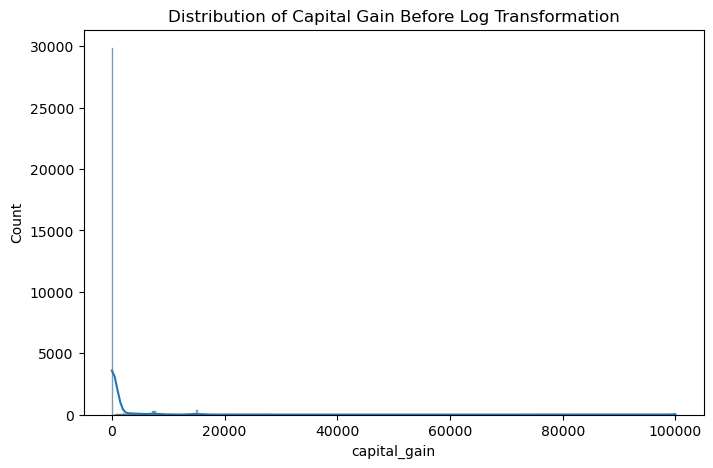

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df['capital_gain'], kde=True)
plt.title("Distribution of Capital Gain Before Log Transformation")
plt.show()

### Skewness Analysis and Log Transformation

I checked the skewness of the numerical features and found that capital_gain had the highest skewness, with a value of approximately 11.95.

To reduce the effect of extreme values, I applied a log transformation using np.log1p(). This was used because the capital_gain column contains zero values.

After the transformation, the skewness decreased from approximately 11.95 to 3.10. This shows that the distribution became less right-skewed, although some skewness is still present.

The log transformation helps reduce the influence of very large values and can make highly skewed numerical features easier to work with during further analysis or Machine Learning.

### Advantages and Disadvantages of Data Transformation

#### Advantages

* Scaling brings numerical features to a similar range, which can help algorithms that are sensitive to feature magnitude.
* Encoding converts categorical values into numerical form so they can be used in machine learning models.
* Log transformation can reduce strong skewness and lessen the influence of extreme values.
* Feature engineering can create useful information from existing variables.

#### Disadvantages

* Some transformations can make the original values harder to interpret.
* One-Hot Encoding can create many additional columns when a categorical feature has many categories.
* Label Encoding can introduce an artificial numerical order between categories when no natural order exists.
* An inappropriate transformation may not improve the data and could affect analysis or model performance.


### Conclusion

In this assignment, I worked on preparing the Adult dataset for further analysis by handling missing values, scaling numerical features, encoding categorical variables, creating new features, and reducing skewness.

Overall, these transformations helped me to make the dataset cleaner and more suitable for further analysis and machine learning.